In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


In [11]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [12]:
df['Car'] = df['Car'].fillna(0)

df = df.drop_duplicates()

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [13]:
print("Check")
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

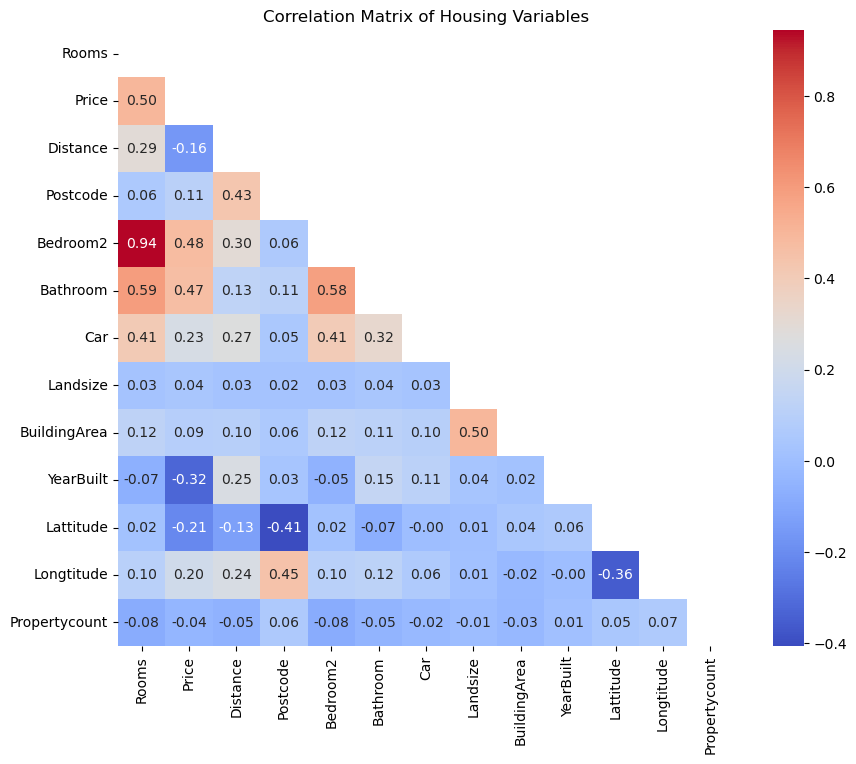

In [14]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [15]:
# remove columns that we do not need
df = df.drop(
    columns=[
        "BuildingArea",
        "SellerG",
        "Date",
        "Postcode",
        "Address",
        "Propertycount",
        "Method",
        "YearBuilt",
        "Suburb",
        "CouncilArea",
        "Bedroom2",],
    errors="ignore",
)

# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: x['Price'] / x['Landsize'],
    Price_per_rooms = lambda x: x['Price'] / x['Rooms'],
    Distance_Category = pd.cut(
        df['Distance'],
        bins=[0, 10, 20, 30, float('inf')],
        labels=['Near', 'Middle', 'Far', 'Outer']
    )
)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

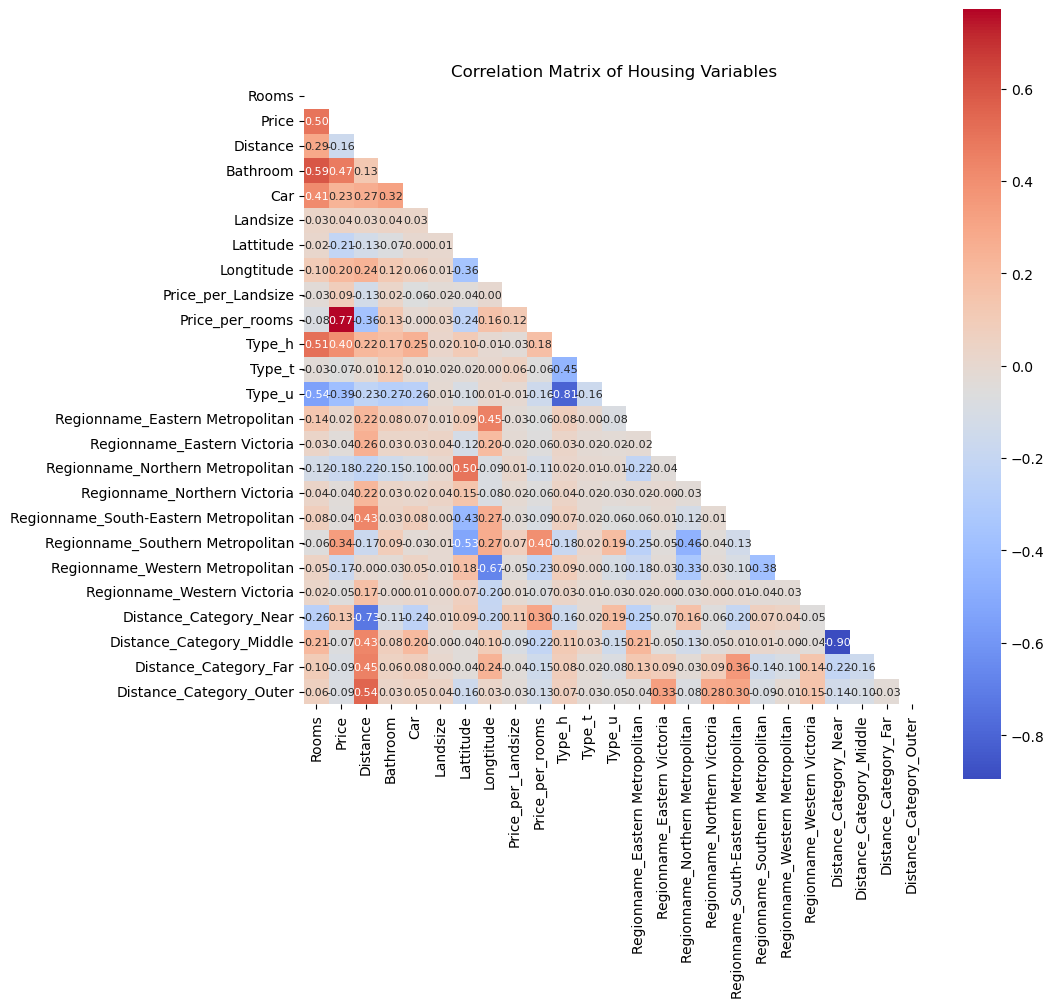

In [16]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname", "Distance_Category"])

# Now calculate correlation on the newly encoded datasetz
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 8})

plt.title("Correlation Matrix of Housing Variables")

In [17]:
# Clean Landsize
Q1_land = df["Landsize"].quantile(0.25)
Q3_land = df["Landsize"].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df = df[(df["Landsize"] >= lower_land) & (df["Landsize"] <= upper_land)]

# Clean Price
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price
df = df[(df["Price"] >= lower_price) & (df["Price"] <= upper_price)]

# Clean Price per landsize
Q1_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.25)
Q3_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.75)
IQR_Price_per_Landsize = Q3_Price_per_Landsize - Q1_Price_per_Landsize
lower_Price_per_Landsize = Q1_Price_per_Landsize - 1.5 * IQR_Price_per_Landsize
upper_Price_per_Landsize = Q3_Price_per_Landsize + 1.5 * IQR_Price_per_Landsize
df = df[(df["Price_per_Landsize"] >= lower_Price_per_Landsize) & (df["Price_per_Landsize"] <= upper_Price_per_Landsize)]


print("Total rows remaining:", len(df))

Total rows remaining: 10579


In [18]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

                   Missing Count  Percentage (%)
Distance_Category              1        0.009453


In [19]:
# remove the 1 missing value for Distance Category
df = df.dropna(subset=["Distance_Category"])
missing_count = df["Distance_Category"].isna().sum()

print(f"Missing values in Distance_category: {missing_count}")

Missing values in Distance_category: 0


In [20]:
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))

Remaining inf values: 0
Total rows remaining: 10578


In [21]:
# 1. Replace all inf and -inf values with NaN in the Price_per_landsize column
df["Price_per_Landsize"] = df["Price_per_Landsize"].replace(
    [np.inf, -np.inf], np.nan
)

# 2. Drop the rows where Price_per_landsize is now NaN
df = df.dropna(subset=["Price_per_Landsize"])

# Verify that all inf values are gone
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))
print(df.shape)

Remaining inf values: 0
Total rows remaining: 10578
(10578, 13)


In [22]:
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
df.head()

,Rooms,Type,Price,Distance,Bathroom,Car,Landsize,Lattitude,Longtitude,Regionname,Price_per_Landsize,Price_per_rooms,Distance_Category
0,2,h,1480000.000,2.500,1.000,1.000,202.000,-37.800,144.998,Northern Metropolitan,7326.733,740000.000,Near
1,2,h,1035000.000,2.500,1.000,0.000,156.000,-37.808,144.993,Northern Metropolitan,6634.615,517500.000,Near
2,3,h,1465000.000,2.500,2.000,0.000,134.000,-37.809,144.994,Northern Metropolitan,10932.836,488333.333,Near
3,3,h,850000.000,2.500,2.000,1.000,94.000,-37.797,144.997,Northern Metropolitan,9042.553,283333.333,Near
5,2,h,941000.000,2.500,1.000,0.000,181.000,-37.804,144.995,Northern Metropolitan,5198.895,470500.000,Near


In [23]:
# Force all numeric columns to exactly 4 decimal places
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].round(4)

# Open your viewer again
# (e.g., your code that opens this interactive table view)

df.to_csv('cleaned_melb_dataset.csv', index = False)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

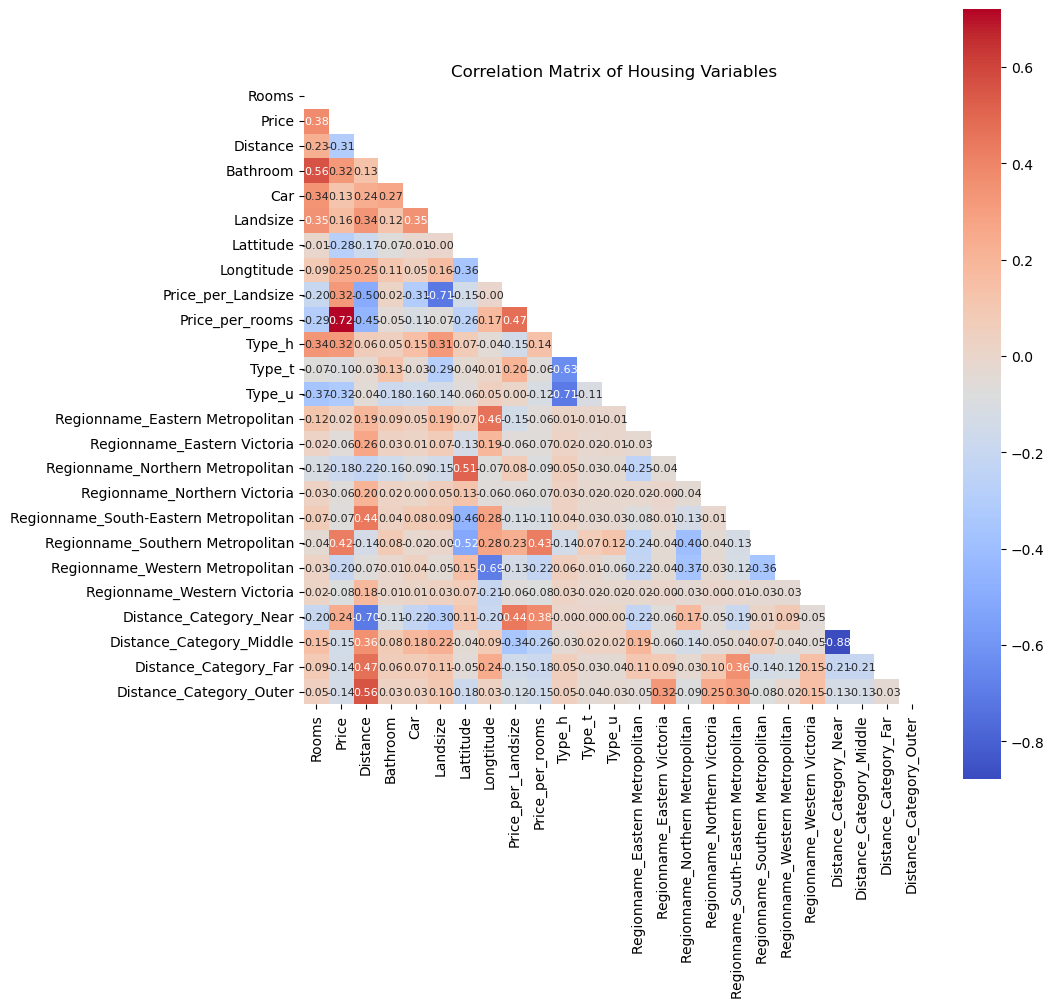

In [24]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname", "Distance_Category"])

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 8})

plt.title("Correlation Matrix of Housing Variables")

In [25]:
y = df_encoded["Price"]

# X_encoded is all columns except price
X_encoded = df_encoded.drop(columns=["Price"])

# This splits your rows into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

# Find Correlation Lists on Training Data
# We combine X_train and y_train to calculate correlation without data leakage
train_data = X_train.copy()
train_data["Price"] = y_train

# Get absolute correlation values with Price
corr = train_data.corr()
price_corr = corr["Price"].abs()


In [22]:
- It splits dataset into an 80% training set and a 20% testing set
- Calculates the absolute correlation coefficients within the traning split

SyntaxError: invalid syntax (3284654547.py, line 1)

Visualizing Feature Correlations with Price


Text(0.5, 1.0, 'Absolute Feature Correlation with Price')

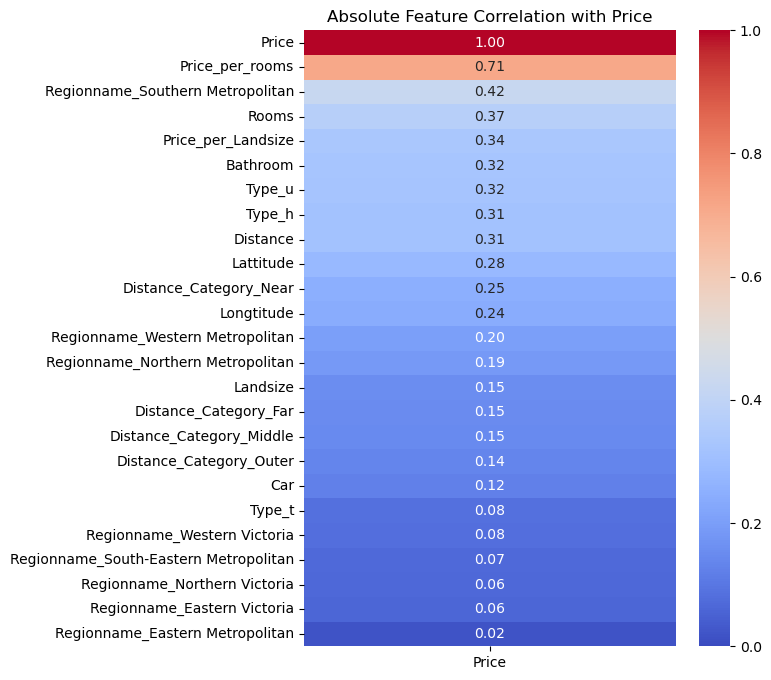

In [26]:
print("Visualizing Feature Correlations with Price")
corr_df = pd.DataFrame(price_corr).sort_values(by="Price", ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".2f")
plt.title("Absolute Feature Correlation with Price")

In [ ]:
- It visually highlights which variaables matter
- Regionname_Sounthern Metropolitan and Rooms are highly correlated which price

In [27]:
strong_features = price_corr[price_corr >= 0.10].index.drop("Price")

# Filter training and testing sets down to these columns
X_train_filtered = X_train[strong_features]
X_test_filtered = X_test[strong_features]

print(f"Dropped {len(X_train.columns) - len(strong_features)} weak features.")
print(f"Remaining features to train on: {list(strong_features)}")

Dropped 6 weak features.
Remaining features to train on: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Price_per_Landsize', 'Price_per_rooms', 'Type_h', 'Type_u', 'Regionname_Northern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Distance_Category_Near', 'Distance_Category_Middle', 'Distance_Category_Far', 'Distance_Category_Outer']


In [ ]:
- It identifies every variable with an absolute correlation of 0.1 or higher against Price.
- We dropped variables with correlation below 0.1 to prevent overfitting and reduce model prediction errors. 

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression(fit_intercept=True)
model.fit(X_train_filtered, y_train)

predictions = model.predict(X_test_filtered)

# Evaluate the final scores
train_score = model.score(X_train_filtered, y_train)
test_score = r2_score(y_test, predictions)

print(f"Training score (R²): {train_score:.3f}")
print(f"Testing score (R²): {test_score:.3f}")

Training score (R²): 0.903
Testing score (R²): 0.925


In [ ]:
- The testing scoore proves that 67.1% of the variance in housing proces, indicating a highly reliable baseline model for evaluation.
- The gap between training score and testing score is only 0.023, they are extremely close to each other.
- This confirms that dropping the weak correlation protected the model form overfitting, making the data more reliable.

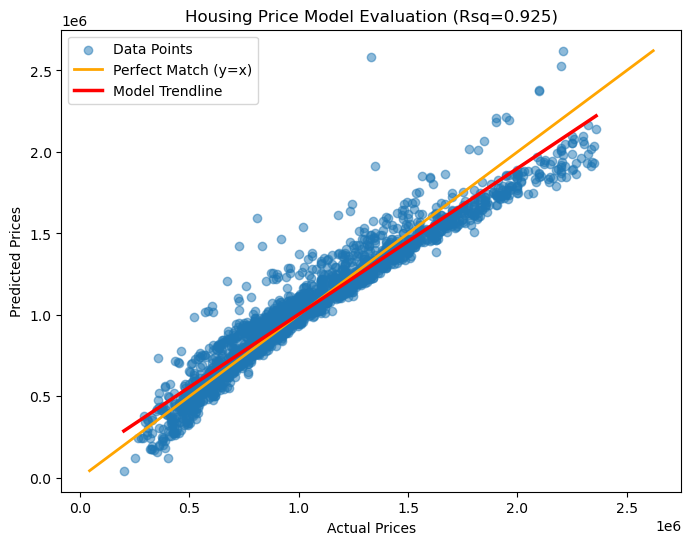

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions, alpha=0.5, label="Data Points")

sns.lineplot(x=predictions, y=predictions, color="orange", label="Perfect Match (y=x)", linewidth=2)

sns.regplot(
    x=y_test, 
    y=predictions, 
    scatter=False, 
    ci=None, 
    line_kws={"color": "red", "linewidth": 2.5}, 
    label="Model Trendline"
)

plt.title(f"Housing Price Model Evaluation (Rsq={test_score:.3f})")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend(loc="upper left")
plt.show()


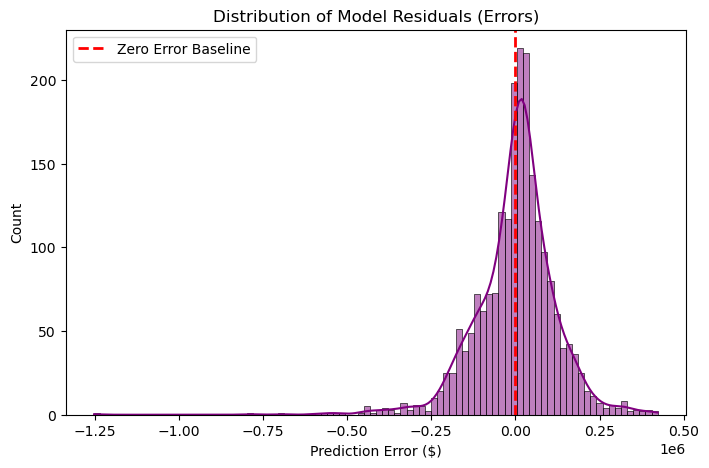

In [30]:
# Calculate the residuals (errors)
residuals = y_test - predictions

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="purple", stat="count")
plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero Error Baseline")

plt.title("Distribution of Model Residuals (Errors)")
plt.xlabel("Prediction Error ($)")
plt.ylabel("Count")
plt.legend()

In [ ]:
- It calculates the prediction errors by subtracting the model prediction feom the actual house prices
- The highest counts peak directly on the zero baseline, it proves the model has zero systematic bias
- The model doesn't lean toward constantly guessing into too high or too low. 

In [31]:
# Print out the diagnostic summary
print("RESIDUALS LOG STATISTICS")
print("Mean of Residuals    :", np.round(residuals.mean(), 3))
print("Std Dev of Residuals :", np.round(residuals.std(), 3))

RESIDUALS LOG STATISTICS
Mean of Residuals    : 909.747
Std Dev of Residuals : 121039.092


In [ ]:
- The mean of residuals measure the overall bias of the model predictions.
- The standard deviation of residuals measure the size and spread of the model mistakes.
- 68% of the model price predictions fall within plus minus $253253.35 of the true market value.

In [32]:
# Print the exact metricsut
print("Training score is", np.round(train_score, 3))
print("Correlation score is", np.round(np.sqrt(train_score), 3))
print("Intercept is", np.round(model.intercept_, 3))

print("\nCoefficients for Each Feature")
coefficients_df = pd.DataFrame({
    'Feature': X_train_filtered.columns,
    'Coefficient': np.round(model.coef_, 3)
})

# Sort them from highest impact to lowest impact
print(coefficients_df.sort_values(by='Coefficient', ascending=False).to_string(index=False))


Training score is 0.903
Correlation score is 0.95
Intercept is -36995987.239

Coefficients for Each Feature
                         Feature  Coefficient
                           Rooms   304675.418
                      Longtitude   212051.023
Regionname_Southern Metropolitan    46243.191
          Distance_Category_Near    39790.723
                          Type_h    17659.825
        Distance_Category_Middle    15953.410
                        Bathroom     9636.401
                             Car     9636.172
 Regionname_Western Metropolitan     5247.885
                        Landsize      165.619
              Price_per_Landsize       19.400
                 Price_per_rooms        2.235
                          Type_u    -2393.770
                        Distance    -4866.803
         Distance_Category_Outer   -17377.511
Regionname_Northern Metropolitan   -21211.308
           Distance_Category_Far   -38366.623
                       Lattitude  -143141.141


In [ ]:
- It shows that expanding structural attributes adds sharp premiums to a property
- The massive values for Longtitude and Lattitude reflect Melbourne geographical landscape.
- Moving East (Lattitude), the price increases and price decreases moving to the south (Longtitude)
- As the feature increases by 1 unit, the price increases by that exact dollar amount